# HW3 Starter notebook : BNN + BBVI

For the original HW3 Instructions from Spring 2026:

<https://www.cs.tufts.edu/cs/145/2026s/hw3.html>

# Clickable Table of Contents

#### Problem 0: Implementing BBVI

* 0a: [sample_nn_params_from_q](#sample_nn_params_from_q)
* 0b: [calc_logpdf_q](#calc_logpdf_q)
* 0c: [calc_elbo_and_grad_from_mc_samples_via_scorefunc_trick](#calc_elbo_and_grad_from_mc_samples_via_scorefunc_trick)
* 0d: [optimize_q_via_stochastic_gradient_ascent](#optimize_q_via_stochastic_gradient_ascent)

#### Problem 1: Diagnostic plots of estimated ELBO and gradients

Verifies your implementation of `calc_logpdf_q` and `calc_elbo_and_grad_from_mc_samples_via_scorefunc_trick`

* [Problem 1a](#problem-1a)
* [Problem 1b](#problem-1b)
* [Problem 1c](#problem-1c)
* [Problem 1d](#problem-1d)
* [Problem 1e](#problem-1e)

#### Problem 2: Run BBVI on COVID-19 data with arch [ ]

Uses `optimize_q_via_stochastic_gradient_ascent`

* [Fig 2a with caption](#problem-2a)
* [Fig 2b with caption](#problem-2b)

#### Problem 3: Run BBVI on COVID-19 data with arch [8]

Uses `optimize_q_via_stochastic_gradient_ascent`

* [Fig 3a with caption](#problem-3a)
* [Fig 3b with caption](#problem-3b)

# Setup

## Import Statements

In [ ]:
# Import numpy and other basic libraries
import numpy as np
import pandas as pd
import copy, datetime, time, os, platform

In [ ]:
## Import JAX
import jax
import jax.numpy as jnp
import jax.scipy.stats as jstats

In [ ]:
# Import packages for plotting
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.25)

In [ ]:
import sklearn.neural_network # for Problem 3
import sklearn.exceptions
import warnings


## Print system info

Useful for debugging

In [ ]:
uname = platform.uname()
B = 10
print("="*B, "Information about OS and CPU", "="*B)
print(f"Node Name: {uname.node}")
print(f"System: {uname.system}")
print(f"Version: {uname.version}")
print(f"Machine: {uname.machine}  Processor: {uname.processor}")
print("Num cores: ", os.cpu_count())

========== Information about OS and CPU ==========
Node Name: Michaels-MacBook-Pro-3.local
System: Darwin
Version: Darwin Kernel Version 22.6.0: Tue Jul 15 08:22:28 PDT 2025; root:xnu-8796.141.3.713.2~2/RELEASE_X86_64
Machine: x86_64  Processor: i386
Num cores:  8


In [ ]:
print("="*B, "Packages in local env", "="*B)
for pkg in [np, jax, matplotlib, sns]:
  print("%12s %s" % (pkg.__name__, pkg.__version__))

========== Packages in local env ==========
       numpy 2.0.2
         jax 0.7.2
  matplotlib 3.10.8
     seaborn 0.13.2


## Colab Setup

### If you are on Google Colab, set `using_colab = True'

Then will clone the github and give you access to the extra .py files and the dataset CSV in starter code

### If not, don't need to do anything as long as you're running in the hw2 directory from starter code


In [ ]:
using_colab = False

In [ ]:
if using_colab:
    if not os.path.exists('cs152BDL-22f-assignments/hw3/'):
        !git clone https://github.com/tufts-ml-courses/cs152BDL-22f-assignments.git 
    os.chdir('cs152BDL-22f-assignments/hw3/')

In [ ]:
# List .py files in current directory, for debugging purposes
# Should see neural_net_utils.py and other .py files from starter code repo
not_windows = uname.system.count("Win") == 0
if not_windows:
    !ls *.py

neural_net_regression_model.py        pytree_arithmetic_utils.py
neural_net_utils.py                   viz_utils_for_posterior_predictive.py


In [ ]:
# List .csv files in current directory, for debugging purposes
# Should see the COVID-19 data file in the starter code repo
if not_windows:
    !ls *.csv

avg_deaths_per_day_in_middlesex_ma_2021__train.csv


## Import utility functions from starter code's external .py files

In [ ]:
from pytree_arithmetic_utils import (
    add_pytrees,
    multiply_pytree_and_scalar,
    subtract_pytree_and_scalar, subtract_pytrees)

In [ ]:
import neural_net_utils

make_nn_params_as_list_of_dicts = neural_net_utils.make_nn_params_as_list_of_dicts
pretty_print_nn_param_list = neural_net_utils.pretty_print_nn_param_list
predict_f_given_x = neural_net_utils.predict_f_given_x

In [ ]:
import neural_net_regression_model as model

calc_logpdf_likelihood = model.calc_logpdf_likelihood
calc_logpdf_prior = model.calc_logpdf_prior
sample_nn_params_from_prior = model.sample_nn_params_from_prior

fast_logpdf_likelihood = jax.jit(calc_logpdf_likelihood)
fast_logpdf_prior = jax.jit(calc_logpdf_prior)

In [ ]:
import viz_utils_for_posterior_predictive as viz_utils

## Set model hyperparameters for Problems 1 and 2

In [ ]:
model1_hypers = {
    'w_mean':0.0, 'b_mean':0.0, 'w_stddev':3.0, 'b_stddev':3.0,
    'tau':0.5}

In [ ]:
W, H = 6, 4  # set width/height of each panel

## Load COVID-19 data from Middlesex County, MA in 2021

Source: NYTimes COVID-19 data on GitHub

Distributed as part of HW3's starter code

In [ ]:
df = pd.read_csv('avg_deaths_per_day_in_middlesex_ma_2021__train.csv')

In [ ]:
raw_x_NF = df['days_since_211207'].astype(np.float32).values[:,np.newaxis].copy()
raw_y_N = df['deaths_avg'].astype(np.float32).values.copy()

In [ ]:
def standardize_array_by_columns(a):
    return (a - np.mean(a, axis=0, keepdims=1)) / np.std(a, axis=0, keepdims=1)

standard_x_NF = standardize_array_by_columns(raw_x_NF)
standard_y_N = standardize_array_by_columns(raw_y_N)

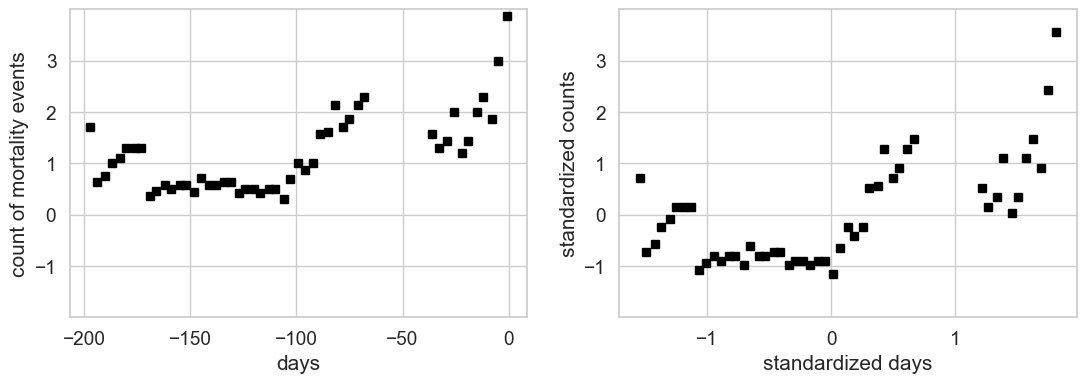

In [ ]:
_, axgrid = plt.subplots(nrows=1, ncols=2, figsize=(W*2+1, H),
                         sharey=False, sharex=False)
axgrid[0].plot(raw_x_NF, raw_y_N, 'ks');
axgrid[0].set_xlabel('days')
axgrid[0].set_ylabel('count of mortality events')
axgrid[1].plot(standard_x_NF, standard_y_N, 'ks');
axgrid[1].set_xlabel('standardized days');
axgrid[1].set_ylabel('standardized counts');
for ax in axgrid:
    ax.set_ylim([-2, 4]);
    ax.set_yticks([-1, 0, 1, 2, 3]);

In [ ]:
# Use standardized data

x_NF = 1.0 * standard_x_NF
y_N = 1.0 * standard_y_N

### Create test grid of x values (size T=501) to use to visualize predictions

In [ ]:
T = 501
xrange = (np.max(x_NF) - np.min(x_NF))
xlo = x_NF.min() - 0.1 * xrange
xhi = x_NF.max() + 0.3 * xrange # show more forward in time
x_grid_T = np.linspace(xlo, xhi, T)
x_grid_T1 = x_grid_T.reshape((T,1))

In [ ]:
print(x_grid_T[:10], '...', x_grid_T[-10:])

[-1.8740586 -1.8646781 -1.8552977 -1.8459172 -1.8365366 -1.8271562
 -1.8177757 -1.8083953 -1.7990148 -1.7896343] ... [2.7317562 2.7411366 2.7505174 2.7598977 2.769278  2.7786584 2.7880392
 2.7974195 2.8068    2.816181 ]


### Softplus : Functions to transform from reals to positives

Used to parameterize our standard deviations, as recommended in the Bayes-by-Backprop paper

In [ ]:
from jax.scipy.special import logsumexp as jax_logsumexp

In [ ]:
def softplus(a):
    return jax_logsumexp(jnp.array([0, a]))
    # Above is equivalent to the line below but more numerically stable
    # return jnp.log(1+jnp.exp(a))
    

In [ ]:
def invsoftplus(b):
    return jnp.log(jnp.exp(b) - 1)

Verify that `softplus` and `invsoftplus` really do invert one another, mapping an input back to its original value.

In [ ]:
invsoftplus(softplus(-3.0))

Array(-3.0000005, dtype=float32)

In [ ]:
invsoftplus(softplus(-1.0))

Array(-1.0000001, dtype=float32)

### Elementwise softplus of a pytree 

In [ ]:
def softplus_of_pytree(pytree):
    return jax.tree.map(lambda a: jax.nn.softplus(a), pytree)

### Utility to fill pytree data struct of nn params with draws from Normal 

In [ ]:
def fill_q_params_with_draws_from_normal(
        n_dims_input=1,
        n_dims_output=1,
        n_dims_per_hidden_list=[],
        mean=0.0,
        stddev=1.0,
        random_state=101):
    ''' Create pytree of NN parameters with random values
    
    Args
    ----
    n_dims_input : int
    n_dims_output : int
    n_dims_per_hidden_list : list of int
    mean : scalar float
    stddev : scalar float
    random_state : int or np.random.RandomState
    
    Returns
    -------
    nn_params : Pytree
    '''
    if isinstance(random_state, int):
        random_state = np.random.RandomState(random_state)
    def fill_func(shape):
        return random_state.normal(mean, stddev, size=shape)
    return make_nn_params_as_list_of_dicts(
        n_dims_input, n_dims_output, n_dims_per_hidden_list,
        weight_fill_func=fill_func,
        bias_fill_func=fill_func)
    

# Problem 0: Implementing BBVI

<a id="sample_nn_params_from_q"></a>

## 0a: Write function to sample nn_params (as pytree) from q

In [ ]:
def sample_nn_params_from_q(
        q_mean_params, q_realstddev_params,
        random_state=42,
        n_samples=1):
    """ Sample values of weights/biases given a specific approx. posterior q
    
    Args
    ----
    q_mean_params : pytree
    q_realstddev_params : pytree
    n_samples : int
    
    Returns
    -------
    nn_params : list of pytree 
        Each element is a nn_params list-of-dicts
    """
    if isinstance(random_state, int):
        random_state = np.random.RandomState(random_state)
        
    all_nn_samples = list()
    L = len(q_mean_params)
    for sample_id in range(n_samples):
        cur_nn_params = list()
        for layer_id in range(L):
            # TODO draw weights/biases for this layer from a Normal
            # with mean determined by contents of q_mean_params
            # with stddev determined by *transformation* of q_realstddev_params
            # HINT: Look at softplus or softplus_of_pytree
            
            w_mean_UV = q_mean_params[layer_id]['w']
            w_UV = 1.0 * w_mean_UV # TODO FIXME draw from normal

            b_mean_V = q_mean_params[layer_id]['b']
            b_V = 1.0 * b_mean_V # TODO FIXME draw from normal
            
            # w_UV is the sampled weights for this layer
            # b_V is array of sampled biases for this layer
            # Pack them away into our list-of-dicts pytree format
            cur_nn_params.append(dict(w=w_UV, b=b_V))
        all_nn_samples.append(cur_nn_params)
    return all_nn_samples

### Quick test of `sample_nn_params_from_q`

In [ ]:
# 1) Create means from Normal 
q_mean_params = fill_q_params_with_draws_from_normal(
    1, 1, [], mean=0.0, stddev=1.0, random_state=101)
pretty_print_nn_param_list(q_mean_params, prefix='mean-of-')

Layer 0
  mean-of-w | shape    (1, 1) | [ 2.707]
  mean-of-b | shape      (1,) | [ 0.628]


In [ ]:
# 2) Create realstddevs that typically map to a stddev around 0.1
q_realstddev_params = fill_q_params_with_draws_from_normal(
    1, 1, [], mean=invsoftplus(0.1), stddev=0.01, random_state=102)
pretty_print_nn_param_list(q_realstddev_params, prefix='rstd-of-')

Layer 0
  rstd-of-w | shape    (1, 1) | [-2.235]
  rstd-of-b | shape      (1,) | [-2.243]


In [ ]:
# 2b) Map realstddev values to stddev params
pretty_print_nn_param_list(softplus_of_pytree(q_realstddev_params), prefix='std-of-')

Layer 0
  std-of-w | shape    (1, 1) | [ 0.102]
  std-of-b | shape      (1,) | [ 0.101]


Now, use the above to draw 10 samples from q

Use the method you just defined: `sample_nn_params_from_q`

In [ ]:
# 3) Draw 10 samples from q defined by the parameters above
nn_samples_S = sample_nn_params_from_q(
    q_mean_params, q_realstddev_params,
    random_state=42,
    n_samples=10)

In [ ]:
print("==== SAMPLE 0")
pretty_print_nn_param_list(nn_samples_S[0])

==== SAMPLE 0
Layer 0
  w | shape    (1, 1) | [ 2.707]
  b | shape      (1,) | [ 0.628]


In [ ]:
print("==== SAMPLE 1")
pretty_print_nn_param_list(nn_samples_S[1])

==== SAMPLE 1
Layer 0
  w | shape    (1, 1) | [ 2.707]
  b | shape      (1,) | [ 0.628]


Your samples should look like draws from a Normal with mean/stddev reported in lines above

<a id="calc_logpdf_q"></a>

## 0b: Write function to evaluate logpdf of q

In [ ]:
def calc_logpdf_q(nn_params, q_mean_params, q_realstddev_params):
    """ Compute logpdf of provided nn weights under q
    
    Args
    ----
    nn_params : pytree
    q_mean_params : pytree, same shape as `nn_params`
    q_realstddev_params : pytree, same shape as `nn_params`
    
    Returns
    -------
    logpdf_q : scalar float
    """
    L = len(nn_params)
    total_logpdf = 0.0
    
    # TODO compute logpdf of q evaluated at nn_params
    # with q a Normal distribution whose params are set to:
    # m = q_mean_params
    # r = q_realstddev_params (convert into stddev via softplus)

    # HINT: Loop over layers 0, 1, ... L-1
    # at each one, grab the w array and b array
    # then plug that into jstats.norm.logpdf
    
    return total_logpdf

### Quick test of `calc_logpdf_q`

Should be able to ask about the logpdf of each of the 10 samples from our earlier quick test

In [ ]:
calc_logpdf_q(nn_samples_S[0], q_mean_params, q_realstddev_params)

0.0

In [ ]:
calc_logpdf_q(nn_samples_S[1], q_mean_params, q_realstddev_params)

0.0

### Function to compute value and gradient of logpdf_q

In [ ]:
# Function to calculate the value of the q logpdf AND its gradients in one call

# Remember that calc_logpdf_q takes args (nn_params, q_means, q_realstddevs)
# so we want grad wrt args numbered 1 and 2 index order (start counting from 0)
calc_value_and_grad_of_logpdf_q = jax.value_and_grad(calc_logpdf_q, argnums=[1,2])
fast_value_and_grad_of_logpdf_q = jax.jit(calc_value_and_grad_of_logpdf_q)

### Quick test of `fast_value_and_grad_of_logpdf_q`

In [ ]:
logpdf, (g_m, g_rs) = fast_value_and_grad_of_logpdf_q(nn_samples_S[1], q_mean_params, q_realstddev_params)
pretty_print_nn_param_list(g_m, prefix='grad-wrt-mean-')
pretty_print_nn_param_list(g_rs, prefix='grad-wrt-realstddev-')

Layer 0
  grad-wrt-mean-w | shape    (1, 1) | [ 0.000]
  grad-wrt-mean-b | shape      (1,) | [ 0.000]
Layer 0
  grad-wrt-realstddev-w | shape    (1, 1) | [ 0.000]
  grad-wrt-realstddev-b | shape      (1,) | [ 0.000]


## Prep for 0c: Calculate Monte-Carlo (MC) estimate of the ELBO

Verify that you know how to do a MC estimate of the ELBO, as discussed on day08 and day09.
This will help you prepare for 0c's `calc_elbo_and_grad_from_mc_samples`

That is, your goal is to implement a function that takes in $S$ samples of the weights-and-biases $\{z^s\}_{s=1}^S$, each drawn iid from $q$ like so:

$$
z^s \sim q( z ; m, r), \hspace{10cm}
$$

Given these $S$ samples, we wish to return a Monte-Carlo estimate of the *1/N rescaled* ELBO defined in the HW3 instructions

\begin{align}
\mathcal{L}(m, r) &\approx
    \frac{1}{NS} \sum_{s=1}^S 
    \Big( \log p(y_{1:N}, z^s) - \log q(z^s ; m, r) 
    \Big)  \hspace{10cm}
\end{align}

Remember that you can compute the **joint** logpdf of $y$ and $z$ by combining the logpdf of likelihood with logpdf of the prior.

Here, the outer $1/N$ scaling helps keep ELBO values in a reasonable range between roughly -10 and 0, instead of values in the -1000s.


In [ ]:
def calc_elbo_from_mc_samples(
        nn_samples_S,
        q_mean_params, q_realstddev_params,
        x_NF=x_NF, y_N=y_N, model_hypers=model1_hypers,
        ):
    """ Estimate the ELBO of q given S samples of nn_params
    
    Args
    ----
    nn_samples_S : list of pytree, length S
    q_mean_params : pytree, same shape as one entry of `nn_samples_S`
        Defines q's mean parameters at each weight/bias
    q_realstddev_params : pytree, same shape as `q_mean_params`
        Defines q's realstddev parameters at each weight/bias

    Returns
    -------
    elbo : scalar float
    """
    N = x_NF.shape[0]
    S = len(nn_samples_S)
    total_elbo = 0.0
    
    # TODO compute ELBO using the provided S MC samples
    # Hint: You should use the provided functions
    # calc_logpdf_likelihood
    # calc_logpdf_prior
    # calc_logpdf_q
    
    return total_elbo / (N * S)

In [ ]:
# Run JIT compiler to get a fast ELBO calculation
fast_elbo_from_mc_samples = jax.jit(calc_elbo_from_mc_samples)

### Quick test of `calc_elbo_from_mc_samples`

Just verify that (1) you produce a scalar float, and (2) the pure-python and fast JIT functions match output

In [ ]:
calc_elbo_from_mc_samples(nn_samples_S, q_mean_params, q_realstddev_params)

0.0

In [ ]:
# Fast version should give the same answer as slow version
fast_elbo_from_mc_samples(nn_samples_S, q_mean_params, q_realstddev_params).item()

0.0

Quick timing experiment. On instructor laptop, we see a speedup of ~50x

Note: if you see a warning like "This could mean that an intermediate result is being cached.", just ignore it.

In [ ]:
%timeit -n3 -r3 calc_elbo_from_mc_samples(nn_samples_S, q_mean_params, q_realstddev_params)

1.7 μs ± 676 ns per loop (mean ± std. dev. of 3 runs, 3 loops each)


In [ ]:
%timeit -n3 -r3 fast_elbo_from_mc_samples(nn_samples_S, q_mean_params, q_realstddev_params)

The slowest run took 9.34 times longer than the fastest. This could mean that an intermediate result is being cached.
136 μs ± 139 μs per loop (mean ± std. dev. of 3 runs, 3 loops each)


<a name="calc_elbo_and_grad_from_mc_samples_via_scorefunc_trick"></a>

## 0c: Calculate ELBO and gradient via score-function trick

Your goal is to implement a function that takes in $S$ samples of the weights-and-biases $\{z^s\}_{s=1}^S$, each drawn iid from $q$ like so:

$$
z^s \sim q( z ; m, r), \hspace{10cm}
$$

Given these $S$ samples, we wish to return the following 3 quantities

\begin{align}
\mathcal{L}(m, r) &\approx
    \frac{1}{NS} \sum_{s=1}^S 
    \Big( \log p(y_{1:N}, z^s) - \log q(z^s ; m, r) 
    \Big)  \hspace{10cm}
    \\
\nabla_{m} \mathcal{L}(m, r) &\approx
    \frac{1}{NS} \sum_{s=1}^S \Big[\nabla_{m} \log q(z^s; m, r)\Big] 
    \Big( \log p(y_{1:N}, z^s) - \log q(z^s ; m, r) 
    \Big)
    \\
\nabla_{r} \mathcal{L}(m, r) &\approx
    \frac{1}{NS} \sum_{s=1}^S \Big[\nabla_{r} \log q(z^s; m, r)\Big] 
    \Big( \log p(y_{1:N}, z^s) - \log q(z^s ; m, r) 
    \Big)    
\end{align}

We do this all in ONE function, since the same S samples can be used to estimate the ELBO and the gradients defined above.

In [ ]:
def calc_elbo_and_grad_from_mc_samples_via_scorefunc_trick(
        nn_samples_S,
        q_mean_params, q_realstddev_params,
        x_NF=x_NF, y_N=y_N, model_hypers=model1_hypers,
        ):
    """ Estimate the ELBO and gradient of q given S samples of nn_params
    
    Args
    ----
    nn_samples_S : list of pytree, length S
    q_mean_params : pytree, same shape as one entry of `nn_samples_S`
        Defines q's mean parameters at each weight/bias
    q_realstddev_params : pytree, same shape as `q_mean_params`
        Defines q's realstddev parameters at each weight/bias
    
    Returns
    -------
    elbo : scalar float
    grad_m : pytree, same shape as `q_mean_params`
        Contains gradient of ELBO wrt each mean parameter of q
    grad_rs : pytree, same shape as `q_realstddev_params`
        Contains gradient of ELBO wrt each realstddev parameter of q
    """
    total_elbo = 0.0
    S = len(nn_samples_S)
    N = y_N.shape[0]
    for ss in range(S):
        # Hint: Variables already defined in current "global" workspace
        # such as x_NF, y_N, model_hypers
        # can be used here without passing them as direct args

        # Get logpdf of q and its gradient with respect to both m and r
        logq, (g_logq_wrt_m, g_logq_wrt_rs) = fast_value_and_grad_of_logpdf_q(
            nn_samples_S[ss], q_mean_params, q_realstddev_params)
        
        cur_elbo = 0.0 # TODO FIXME
        total_elbo += cur_elbo
        
        # Accumulate total gradient by adding in latest gradient
        if ss == 0:
            total_grad_m = g_logq_wrt_m   # TODO FIXME
            total_grad_rs = g_logq_wrt_rs # TODO FIXME
        else:
            # Hint: Use add_pytrees here to accumulate samples > 0
            total_grad_m = total_grad_m   # TODO FIXME
            total_grad_rs = total_grad_rs # TODO FIXME

    # Return totals (summed across all S samples) divided by S
    return (
        total_elbo / (N * S),
        multiply_pytree_and_scalar(total_grad_m, 1.0/(N * S)),
        multiply_pytree_and_scalar(total_grad_rs, 1.0/(N * S)))

In [ ]:
fast_elbo_and_grad_from_mc_samples = jax.jit(calc_elbo_and_grad_from_mc_samples_via_scorefunc_trick)

## Provided Utility: `fast_elbo_and_grad`

The function `fast_elbo_and_grad` just calls two functions you already wrote

* your `sample_nn_params_from_q` from 0a
* your JIT-accelerated `calc_elbo_and_grad_from_mc_samples_via_scorefunc_trick` from 0c

It combines *sampling* from $q$ with using those samples to compute the ELBO + gradients

In [ ]:
def fast_elbo_and_grad(
        q_mean_params, q_realstddev_params,
        n_samples=1,
        random_state=42,
        x_NF=x_NF, y_N=y_N, model_hypers=model1_hypers,
        ):
    ''' Compute ELBO and grad wrt means and realstddevs of q
    
    Performs sampling from q (not JIT-able currently)
    followed by fast ELBO and gradient calculation (JIT-able)
    
    Args
    ---
    q_mean_params
    q_realstddev_params
    n_samples : int
        Number of MC samples to use
    random_state : int or np.random.RandomState
    
    Returns
    -------
    elbo : scalar float
    grad_m : pytree, same shape as `q_mean_params`
        Contains gradient of ELBO wrt each mean parameter of q
    grad_rs : pytree, same shape as `q_realstddev_params`
        Contains gradient of ELBO wrt each realstddev parameter of q
    '''
    nn_samples_S = sample_nn_params_from_q(
        q_mean_params, q_realstddev_params,
        n_samples=n_samples,
        random_state=random_state)
    return fast_elbo_and_grad_from_mc_samples(
        nn_samples_S, q_mean_params, q_realstddev_params,
        x_NF=x_NF, y_N=y_N, model_hypers=model_hypers)

### Quick test of `fast_elbo_and_grad` via 10 samples and arch []

In [ ]:
elbo, gm, grs = fast_elbo_and_grad(q_mean_params, q_realstddev_params, n_samples=10)
print("ELBO: %.6f" % elbo)
print("--- grad wrt MEANS")
pretty_print_nn_param_list(gm, "grad-wrt-m-of-")
print("--- grad wrt REALSTDDEVS")
pretty_print_nn_param_list(grs, "grad-wrt-rsd-of-")

ELBO: 0.000000
--- grad wrt MEANS
Layer 0
  grad-wrt-m-of-w | shape    (1, 1) | [ 0.000]
  grad-wrt-m-of-b | shape      (1,) | [ 0.000]
--- grad wrt REALSTDDEVS
Layer 0
  grad-wrt-rsd-of-w | shape    (1, 1) | [ 0.000]
  grad-wrt-rsd-of-b | shape      (1,) | [ 0.000]


### Quick test of `fast_elbo_and_grad` via 20 samples and arch [4]

In [ ]:
qm4 = fill_q_params_with_draws_from_normal(1,1,[4], 0.0, 1.0)
qrs4 = fill_q_params_with_draws_from_normal(1,1,[4], invsoftplus(0.1), 0.05)
elbo, gm, grs = fast_elbo_and_grad(qm4, qrs4, n_samples=20)

print("ELBO: %.6f" % elbo)
print("Gradient wrt MEANS")
pretty_print_nn_param_list(gm, "grad-wrt-m-of-")
print("Gradient wrt REALSTDDEVS")
pretty_print_nn_param_list(grs, "grad-wrt-rsd-of-")

ELBO: 0.000000
Gradient wrt MEANS
Layer 0
  grad-wrt-m-of-w | shape    (1, 4) | [ 0.000  0.000  0.000  0.000]
  grad-wrt-m-of-b | shape      (4,) | [ 0.000  0.000  0.000  0.000]
Layer 1
  grad-wrt-m-of-w | shape    (4, 1) | [ 0.000  0.000  0.000  0.000]
  grad-wrt-m-of-b | shape      (1,) | [ 0.000]
Gradient wrt REALSTDDEVS
Layer 0
  grad-wrt-rsd-of-w | shape    (1, 4) | [ 0.000  0.000  0.000  0.000]
  grad-wrt-rsd-of-b | shape      (4,) | [ 0.000  0.000  0.000  0.000]
Layer 1
  grad-wrt-rsd-of-w | shape    (4, 1) | [ 0.000  0.000  0.000  0.000]
  grad-wrt-rsd-of-b | shape      (1,) | [ 0.000]


More tests are possible! Feel free to skip ahead to Problem 1a and 1b

<a id="optimize_q_via_stochastic_gradient_ascent"></a>

## 0d: Implement `optimize_q_via_stochastic_gradient_ascent`

Here, we're writing code to solve the following optimization problem: maximize the 1/N-rescaled ELBO

$$
m^*, r^* \gets \arg\!\max_{m, r} \mathcal{L}(m, r)
$$

We'll use stochastic gradient *ascent* because we're maximizing, not minimizing so we want to climb uphill.
We'll use a version with *constant step size*.

Most of the code is provided for you, you just need to edit one part: the update to parameters.

**Look for the "TODO FIXME" lines**, and edit those directly.

In [ ]:
def optimize_q_via_stochastic_gradient_ascent(
        init_q_means,
        init_q_realstddevs,
        n_iters=100,
        step_size_m=0.001,
        step_size_rs=0.001,
        n_mc_samples=100,
        random_state=101,
        print_early=3,
        print_every=100,
        print_max_num_weights=2, # set to zero to print no weight info
        x_NF=x_NF,
        y_N=y_N,
        model_hypers=model1_hypers,      
        ):
    ''' Run Black-Box VI stochastic gradient ascent
    
    Each iteration computes a noisy gradient of ELBO and nudges q's parameters uphill

    Args
    ----
    init_q_means : pytree
    init_q_realstddevs : pytree
    n_iters : int
        Total number of iterations to run
    step_size_m : float
        Step size for gradient updates of mean parameters
    step_size_rs : float
        Step size for gradient updates of realstddev parameters
    n_mc_samples : int
        Number of MC samples to use
    random_state : int or np.random.RandomState

    Returns
    -------
    opt_q_means : pytree
        Optimized values of q_means
    opt_q_realstddevs : pytree
        Optimized values of q_realstddevs
    history : dict
        Contains history of this optimization run
        Useful for trace plots
    '''
    history = dict(
        n_mc_samples=n_mc_samples,
        step_size_m=step_size_m,
        step_size_rs=step_size_rs,
        iter=list(),
        elbo=list(),
        q_m=list(),
        q_rs=list(),
        )
    if isinstance(random_state, int):
        random_state = np.random.RandomState(random_state)
    
    q_means = init_q_means
    q_realstddevs = init_q_realstddevs
    
    print("S = %6s | step_size of m %.6g | step_size of rs %.6g" % (
        n_mc_samples, step_size_m, step_size_rs))
    start_time = time.time()
    for iter_id in range(n_iters+1):
        
        if iter_id > 0:
            # Update parameters to go uphill
            # Take step along gradient of provided length
            q_means = multiply_pytree_and_scalar(q_means, 1.0) # TODO FIXME
            q_realstddevs = multiply_pytree_and_scalar(q_realstddevs, 1.0) # TODO FIXME
            
        # Estimate ELBO and gradient at current params
        elbo, grad_elbo_wrt_m, grad_elbo_wrt_rs = fast_elbo_and_grad(
            q_means, q_realstddevs, 
            n_samples=n_mc_samples,
            random_state=random_state,
            x_NF=x_NF, y_N=y_N, model_hypers=model_hypers)

        if not np.isfinite(elbo):
            print("EARLY TERMINATION DUE TO NaN")
            break
        
        # Record current state of algorithm to history
        history['iter'].append(iter_id)
        history['elbo'].append(elbo)
        history['q_m'].append(q_means)
        history['q_rs'].append(q_realstddevs)
        
        # Print a status update every few iterations
        if iter_id < print_early or (iter_id % print_every == 0) or iter_id == n_iters:
            msg = "iter %6d/%d after %5.1f sec  ELBO % .6e" % (
                iter_id, n_iters, time.time() - start_time, elbo)
            if print_max_num_weights > 0:
                with np.printoptions(formatter={'float': '{: 0.3f}'.format}):
                    for layer_id in range(len(q_means)):
                        m_str = str(q_means[layer_id]['w'].flatten()[:print_max_num_weights])
                        rs_str = str(q_realstddevs[layer_id]['w'].flatten()[:print_max_num_weights])
                        msg += "  m= %s  r= %s" % (m_str, rs_str)
            print(msg)
                
    for key in ['iter', 'elbo']:
        history[key] = np.asarray(history[key])
    return q_means, q_realstddevs, history

# Problem 1

### Define "close to ideal" q, based on EXACT posterior for arch []

See instructions on website for motivation for this "ideal" q for Problem 1

Set slope "w" to mean 0.659, stddev 0.3  
Set bias "b" to mean 0.000, stddev 0.3 

In [ ]:
target_stddev_for_q = 0.3

In [ ]:
# Create data struct with right shapes filled randomly, then overwrite with desired values.
ideal_q_means = fill_q_params_with_draws_from_normal(1, 1, [], mean=0.0, stddev=0.0001, random_state=42)
ideal_q_means[0]['w'][:] = 0.659  # Using result from exact posterior code from HW2 Problem 2
ideal_q_means[0]['b'][:] = 0.0

In [ ]:
# Fill stddev params
ideal_q_realstddevs = fill_q_params_with_draws_from_normal(
    1, 1, [],
    mean=invsoftplus(target_stddev_for_q),
    stddev=0.0001, random_state=42)

In [ ]:
pretty_print_nn_param_list(ideal_q_means, prefix='qideal mean of ')
pretty_print_nn_param_list(softplus_of_pytree(ideal_q_realstddevs), prefix='qideal stddev of ')

Layer 0
  qideal mean of w | shape    (1, 1) | [ 0.659]
  qideal mean of b | shape      (1,) | [ 0.000]
Layer 0
  qideal stddev of w | shape    (1, 1) | [ 0.300]
  qideal stddev of b | shape      (1,) | [ 0.300]


### Define a "bad" q, with near-zero means and not-too-small stddevs

Instead of the positive linear trend of the "ideal" model, we're capturing a boring flat prediction that doesn't fit data well.

In [ ]:
bad_q_means = fill_q_params_with_draws_from_normal(
    1, 1, [], mean=0.0, stddev=0.0001, random_state=42)

In [ ]:
bad_q_realstddevs = fill_q_params_with_draws_from_normal(
    1, 1, [],
    mean=invsoftplus(target_stddev_for_q),
    stddev=0.0001, random_state=42)

In [ ]:
pretty_print_nn_param_list(bad_q_means, prefix='qbad mean of ')
pretty_print_nn_param_list(softplus_of_pytree(bad_q_realstddevs), prefix='qbad stddev of ')

Layer 0
  qbad mean of w | shape    (1, 1) | [ 0.000]
  qbad mean of b | shape      (1,) | [-0.000]
Layer 0
  qbad stddev of w | shape    (1, 1) | [ 0.300]
  qbad stddev of b | shape      (1,) | [ 0.300]


### Now compare the ELBO at ideal q and at bad q

We should see near-ideal q has HIGHER elbo

#### ELBO at "bad" q, using 50 samples repeated 3x

In [ ]:
prng = np.random.RandomState(123456)
for rep in range(3):
    elbo, _, _ = fast_elbo_and_grad(bad_q_means, bad_q_realstddevs, 50, prng)
    print(elbo)

0.0
0.0
0.0


#### ELBO at "near-ideal" q, using 50 samples repeated 3x

In [ ]:
prng = np.random.RandomState(123456)
for rep in range(3):
    elbo, _, _ = fast_elbo_and_grad(ideal_q_means, ideal_q_realstddevs, 50, prng)
    print(elbo)

0.0
0.0
0.0


<a name="problem-1a"></a>

## Prep for 1a

**Statement**: Create 1 row x 3 column panels of the estimated ELBO as function of mean of w

* Each column should show results using 1, 10, and 100 samples
* Each panel should show the estimated value of $\mathcal{L}$ across several possible settings of $q$'s parameter vector
* * Let $m$ (the mean of 𝑤 under 𝑞) vary across a grid of 20 possible values
* * Fix the other parameters of $q()$ to their Close-to-Ideal values defined above


In [ ]:
n_samples_M = np.asarray([1, 10, 100])
M = n_samples_M.size

In [ ]:
# Create grid of candidate values for the mean of w
G = 21
ideal_mu = ideal_q_means[0]['w'][0,0]
mean_grid_G = np.linspace(ideal_mu - 4, ideal_mu + 4, G)

In [ ]:
# Compute elbo at each candidate in grid
elbo_grid_GM = np.zeros((G, M))
    
for gg, w_mean in enumerate(mean_grid_G):
    cur_q_means = copy.deepcopy(ideal_q_means)
    cur_q_means[0]['w'][:] = w_mean
    for mm, n_mc_samples in enumerate(n_samples_M):
        random_state = 10000 * (mm+1) + gg
        elbo_grid_GM[gg, mm], _, _ = fast_elbo_and_grad(
            cur_q_means, ideal_q_realstddevs, n_mc_samples, random_state)

## Figure 1a

**STATEMENT**: Make a 1 row x 3 column plot of the estimated 1/N-rescaled ELBO as function of $m$

Best w_mean: -3.341


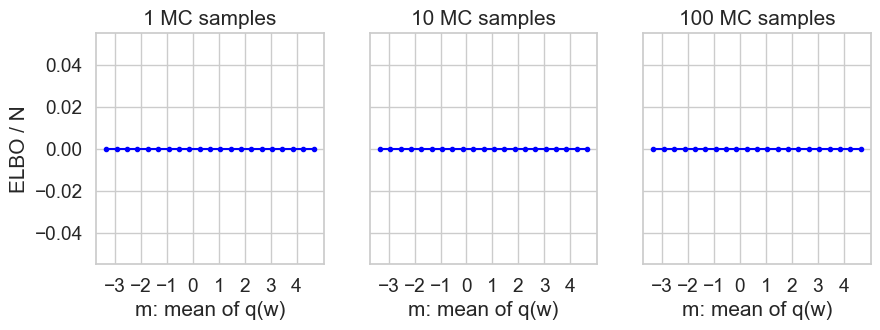

In [ ]:
_, subplot_grid = plt.subplots(
    nrows=1, ncols=M, figsize=(3*M+1, 3), sharex=True, sharey=True, squeeze=False)

for mm in range(M):
    ax = subplot_grid[0,mm]
    ax.plot(mean_grid_G, elbo_grid_GM[:,mm], 'b.-')
    ax.set_title('%d MC samples' % n_samples_M[mm])
    ax.set_xlabel('m: mean of q(w)'); ax.set_xticks([-3, -2, -1, 0, 1, 2, 3, 4]);
    if mm == 0:
        ax.set_ylabel("ELBO / N")
        
print("Best w_mean: " + str(mean_grid_G[elbo_grid_GM[:,-1].argmax()]))

In [ ]:
print("Remember, Fig 1a we are")
print("  - systematically varying the mean of w, replacing NaN below with value of x axis")
print("  - otherwise freezing q parameters to values found below")
cur_q_means[0]['w'][:] = np.nan
pretty_print_nn_param_list(cur_q_means, 'q mean of ')
pretty_print_nn_param_list(softplus_of_pytree(ideal_q_realstddevs), 'q stddev of ')

Remember, Fig 1a we are
  - systematically varying the mean of w, replacing NaN below with value of x axis
  - otherwise freezing q parameters to values found below
Layer 0
  q mean of w | shape    (1, 1) | [ nan]
  q mean of b | shape      (1,) | [ 0.000]
Layer 0
  q stddev of w | shape    (1, 1) | [ 0.300]
  q stddev of b | shape      (1,) | [ 0.300]


<a name="problem-1b"></a>

## Prep for 1b

In [ ]:
grad_m_grid_GM = np.zeros((G, M))

for gg, w_mean in enumerate(mean_grid_G):
    cur_q_means = copy.deepcopy(ideal_q_means)
    cur_q_means[0]['w'][:] = w_mean
    for mm, n_samples in enumerate(n_samples_M):
        random_state = 10000 * (mm+1) + gg
        _, grad_wrt_m, grad_wrt_rs = fast_elbo_and_grad(
            cur_q_means, ideal_q_realstddevs, 
            n_samples, random_state)
        grad_m_grid_GM[gg, mm] = grad_wrt_m[0]['w'][0,0]

## Figure 1b

**STATEMENT**: Make a 1 row x 3 column plot of the estimated gradient of the 1/N-rescaled ELBO w.r.t $m$

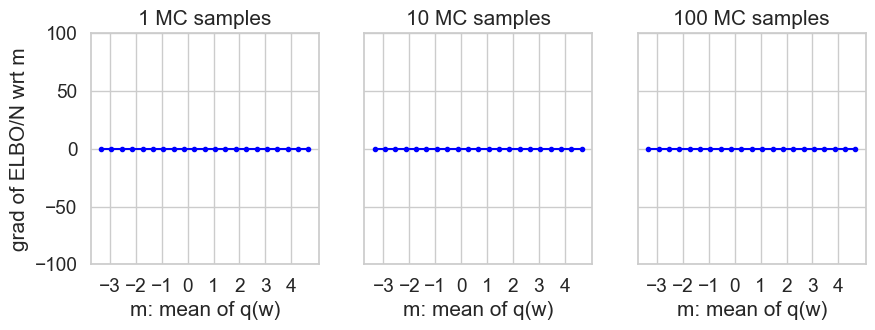

In [ ]:
_, subplot_grid = plt.subplots(
    nrows=1, ncols=M, figsize=(3*M+1, 3), sharex=True, sharey=True, squeeze=False)

for mm in range(M):
    ax = subplot_grid[0,mm]
    ax.plot(mean_grid_G, grad_m_grid_GM[:,mm], 'b.-')
    ax.set_title('%d MC samples' % n_samples_M[mm])
    ax.set_xlabel('m: mean of q(w)'); ax.set_xticks([-3, -2, -1, 0, 1, 2, 3, 4]);
    if mm == 0:
        ax.set_ylabel('grad of ELBO/N wrt m');
    ax.set_ylim([-100, 100]); # KEEP THESE y lims, good solutions should look good with these

<a name="problem-1d"></a>

<a name="problem-1c"></a>

## Prep for 1c

In [ ]:
# Grid of realstddev values to try
ideal_w_realstddev = ideal_q_realstddevs[0]['w'][0,0]
realstddev_grid_G = np.linspace(ideal_w_realstddev - 3, ideal_w_realstddev + 3, G)

In [ ]:
elbo2_grid_GM = np.zeros((G, M))
    
for gg, w_realstddev in enumerate(realstddev_grid_G):
    cur_q_realstddevs = copy.deepcopy(ideal_q_realstddevs)
    cur_q_realstddevs[0]['w'][:] = w_realstddev
    for mm, n_mc_samples in enumerate(n_samples_M):
        random_state = 10000 * (mm+1) + gg
        elbo2_grid_GM[gg, mm], _, _ = fast_elbo_and_grad(
            ideal_q_means, cur_q_realstddevs, n_mc_samples, random_state)
        
print("Best realstddev for w: " + str(realstddev_grid_G[elbo2_grid_GM[:,-1].argmax()]))
print("Best stddev for w    : " + str(softplus(realstddev_grid_G[elbo2_grid_GM[:,-1].argmax()])))

Best realstddev for w: -4.0501760632953925
Best stddev for w    : 0.017269362


## Figure 1c

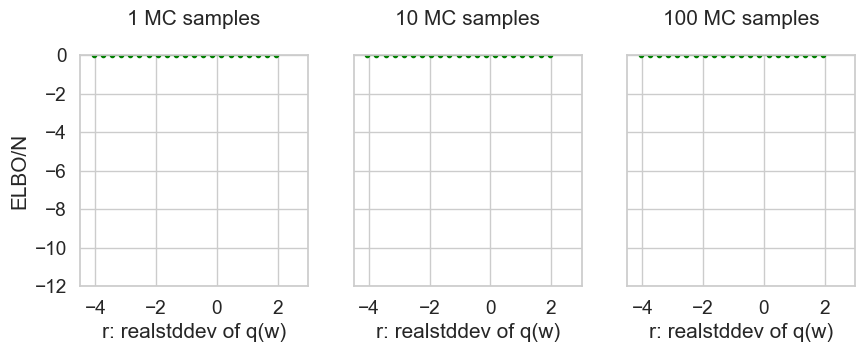

In [ ]:
_, subplot_grid = plt.subplots(
    nrows=1, ncols=M, figsize=(3*M+1, 3),
    sharex=True, sharey=True, squeeze=False)
for mm in range(M):
    ax = subplot_grid[0,mm]
    ax.plot(realstddev_grid_G, elbo2_grid_GM[:,mm], 'g.-')
    ax.set_title('%d MC samples\n' % n_samples_M[mm])
    ax.set_xlabel('r: realstddev of q(w)')
    xticks = np.asarray([-4, -2, 0, 2]);
    ax.set_xticks(xticks)
subplot_grid[0,0].set_ylabel('ELBO/N');
plt.ylim([-12, 0]);
plt.xlim([-4.5, 3]);

In [ ]:
print("Remember, Fig 1c we are")
print("  - systematically varying q's stddev of w, replacing NaN below with value of x axis")
print("  - otherwise freezing q parameters to values found below")
cur_q_realstddevs[0]['w'][:] = np.nan
pretty_print_nn_param_list(ideal_q_means, 'q mean of ')
pretty_print_nn_param_list(softplus_of_pytree(cur_q_realstddevs), 'q stddev of ')

Remember, Fig 1c we are
  - systematically varying q's stddev of w, replacing NaN below with value of x axis
  - otherwise freezing q parameters to values found below
Layer 0
  q mean of w | shape    (1, 1) | [ 0.659]
  q mean of b | shape      (1,) | [ 0.000]
Layer 0
  q stddev of w | shape    (1, 1) | [ nan]
  q stddev of b | shape      (1,) | [ 0.300]


<a name="problem-1d"></a>

## Prep for 1d

In [ ]:
grad_rs_grid_GM = np.zeros((G, M))

for gg, w_realstddev in enumerate(realstddev_grid_G):
    cur_q_rs = copy.deepcopy(ideal_q_realstddevs)
    cur_q_rs[0]['w'][:] = w_realstddev
    for mm, n_samples in enumerate(n_samples_M):
        random_state = 10000 * (mm+1) + gg
        _, grad_wrt_m, grad_wrt_rs = fast_elbo_and_grad(
            ideal_q_means, cur_q_rs, 
            n_samples, random_state)
        grad_rs_grid_GM[gg, mm] = grad_wrt_rs[0]['w'][0,0]

## Figure 1d

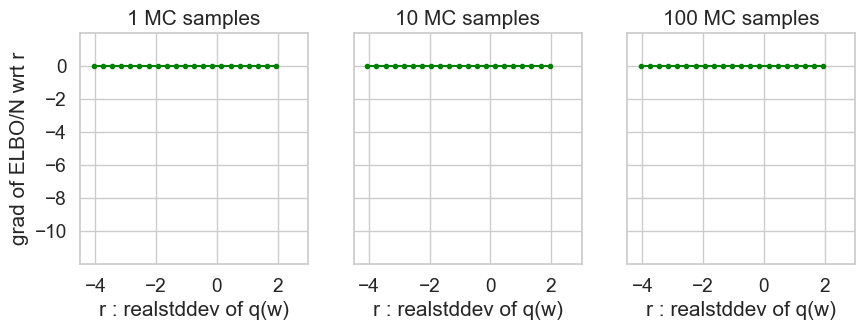

In [ ]:
_, subplot_grid = plt.subplots(nrows=1, ncols=M, figsize=(3*M+1, 3), sharex=True, sharey=True, squeeze=False)

for mm in range(M):
    ax = subplot_grid[0,mm]
    ax.plot(realstddev_grid_G, grad_rs_grid_GM[:,mm], 'g.-')
    ax.set_title('%d MC samples' % n_samples_M[mm])
    ax.set_xlabel('r : realstddev of q(w)');
    xticks = np.asarray([-4, -2, 0, 2]);
    ax.set_xticks(xticks);
    if mm == 0:
        ax.set_ylabel('grad of ELBO/N wrt r');
plt.ylim([-12, 2]);
plt.yticks([-10, -8, -6, -4, -2, 0]);
plt.xlim([-4.5, 3]);

<a name="problem-1e"></a>

## Problem 1e

**SOLUTION**: 

TODO WRITE IN REPORT

<a name="run_bbvi"></a>

# Problem 2: NN regression on COVID-19 data with linear model (arch [ ])

Let's use BBVI to estimate a posterior over weights for the linear model.

We'll need to carefully tune the following:

* `n_mc_samples` : Number of MC samples 
* `step_size_m` : step_size for the mean parameters of q
* `step_size_rs` : step_size for the realstddev parameters of q
* `n_iters` : how long to run the optimization

The code below offers a "multi-phase" approach to calling the gradient ascent.

Each phase uses a constant setting (num samples, step size etc), and then its result becomes the start of the next phase.

**TODO FIXME** edit the following to achieve convergence

In [ ]:
S_by_phase = {0:10, 1:10}          # TODO FIXME edit these
ssm_by_phase = {0:0.001, 1:0.001}  # TODO FIXME edit these
ssr_by_phase = {0:0.001, 1:0.001}  # TODO FIXME edit these
n_iters_by_phase = {0:10, 1:10}    # TODO FIXME edit these

In [ ]:
arch0 = []
chain_list = [1,2,3]

# Preallocate where to store results
qm_by_chain = {}
qrs_by_chain = {}
history_by_chain = {}

## Prep for 2a: Run the experiments

In [ ]:
for chain_id in chain_list:
    random_state = 100 * rep + chain_id
    
    # Initialize the m and r parameters of q
    q_means = fill_q_params_with_draws_from_normal(
        1, 1, arch0,
        mean=0.0,
        stddev=1.0,
        random_state=random_state)
    q_rs = fill_q_params_with_draws_from_normal(
        1, 1, arch0,
        mean=invsoftplus(0.5), # typical stddev should be 0.5
        stddev=0.5,
        random_state=random_state)
    print()
    for phase in S_by_phase.keys():
        print("Chain %d/%d phase %d" % (chain_id, len(chain_list), phase))
        q_means, q_rs, hist = optimize_q_via_stochastic_gradient_ascent(
            q_means, q_rs,
            n_mc_samples=S_by_phase[phase],
            step_size_m=ssm_by_phase[phase],
            step_size_rs=ssr_by_phase[phase],
            random_state=random_state,
            print_every=100,
            n_iters=n_iters_by_phase[phase])
        qm_by_chain[chain_id] = q_means
        qrs_by_chain[chain_id] = q_rs
        history_by_chain[(chain_id, phase)] = hist


Chain 1/3 phase 0
S =     10 | step_size of m 0.001 | step_size of rs 0.001
iter      0/10 after   0.0 sec  ELBO  0.000000e+00  m= [ 0.317]  r= [-0.274]
iter      1/10 after   0.0 sec  ELBO  0.000000e+00  m= [ 0.317]  r= [-0.274]
iter      2/10 after   0.0 sec  ELBO  0.000000e+00  m= [ 0.317]  r= [-0.274]
iter     10/10 after   0.0 sec  ELBO  0.000000e+00  m= [ 0.317]  r= [-0.274]
Chain 1/3 phase 1
S =     10 | step_size of m 0.001 | step_size of rs 0.001
iter      0/10 after   0.0 sec  ELBO  0.000000e+00  m= [ 0.317]  r= [-0.274]
iter      1/10 after   0.0 sec  ELBO  0.000000e+00  m= [ 0.317]  r= [-0.274]
iter      2/10 after   0.0 sec  ELBO  0.000000e+00  m= [ 0.317]  r= [-0.274]
iter     10/10 after   0.0 sec  ELBO  0.000000e+00  m= [ 0.317]  r= [-0.274]

Chain 2/3 phase 0
S =     10 | step_size of m 0.001 | step_size of rs 0.001
iter      0/10 after   0.0 sec  ELBO  0.000000e+00  m= [-0.736]  r= [-0.801]
iter      1/10 after   0.0 sec  ELBO  0.000000e+00  m= [-0.736]  r= [-0.801]


<a id="problem-2a"></a>

## Figure 2a : ELBO, means, and realstddevs over iterations

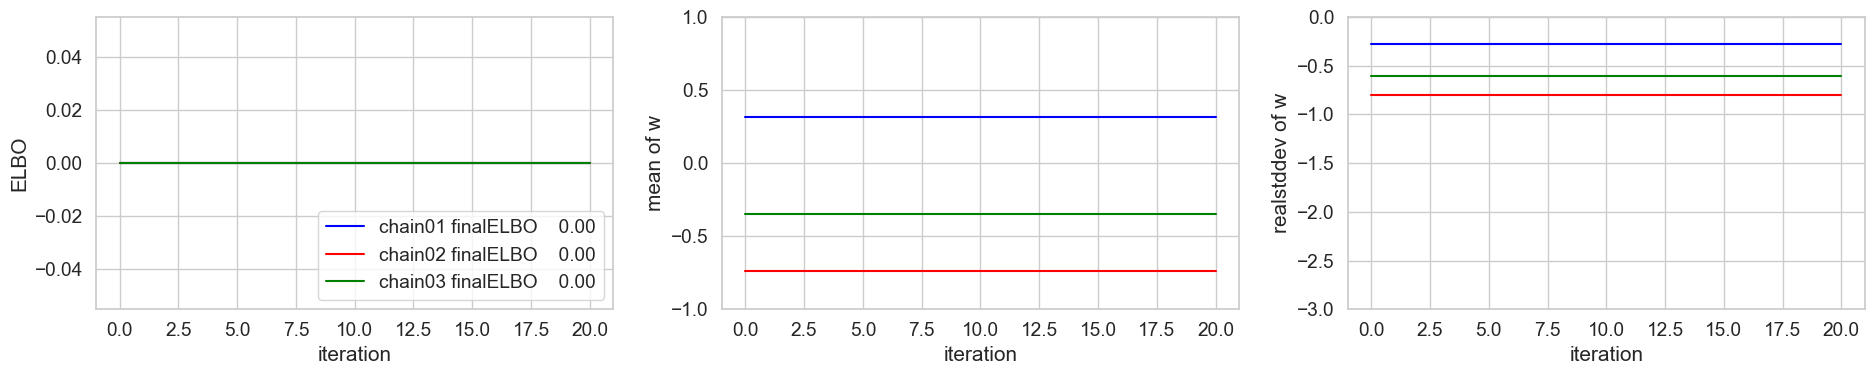

In [ ]:
color_by_chain = {1:'b', 2:'r', 3:'g'}
_, axgrid = plt.subplots(nrows=1, ncols=3, figsize=(3*W+1, H),
                         sharex=True, sharey=False)

phase_list = list(sorted(S_by_phase.keys()))
for chain in chain_list:
    color = color_by_chain[chain]
    M = 0
    for phase in phase_list:
        iter_T = history_by_chain[(chain,phase)]['iter']
        elbo_T = history_by_chain[(chain,phase)]['elbo']
        label = 'chain%02d finalELBO % 7.2f' % (chain, elbo_T[-10:].mean()) if phase == phase_list[-1] else None                                                if rep == 2 else None
        axgrid[0].plot(M + iter_T, elbo_T, color=color, linestyle='-', label=label)
        
        m_T = [mlist[-1]['w'].flatten() for mlist in history_by_chain[(chain,phase)]['q_m']]
        axgrid[1].plot(M + iter_T, m_T, color=color, linestyle='-')
        
        rs_T = [rlist[-1]['w'].flatten() for rlist in history_by_chain[(chain,phase)]['q_rs']]
        axgrid[2].plot(M + iter_T, rs_T, color=color, linestyle='-')

        M += iter_T.max();

axgrid[0].set_ylabel("ELBO"); axgrid[0].legend(loc='lower right');
axgrid[1].set_ylabel("mean of w"); axgrid[1].set_ylim([-1.0, 1.0]);
axgrid[2].set_ylabel("realstddev of w"); axgrid[2].set_ylim([-3.0, 0.0]);
for ax in axgrid:
    ax.set_xlabel('iteration');
#axgrid[0].set_ylim([-3, -1.4]); # TODO use these ylims if possible
plt.tight_layout();

### **Caption for Fig 2a:**  TODO Write this

TODO in your report

* the specific number of Monte Carlo samples and step-sizes used
* 1-2 sentences summarizing your strategy for selecting these values
* your assessment of whether the plots indicate each chain has "converged"

## Prep for Fig 2b

Given the optimal $q$ from each chain above, let's look at its posterior predictive by:

* Drawing $S$ samples of weights/biases from q
* Drawing $S$ samples of $y_*$ at each of the $T$ test inputs $x_*$ defined above (see defn of x_grid_T1)

We can then *reuse* the posterior predictive visualization tools from HW2.

The following code works *almost* out of the box.

**TODO FIXME**: Edit the FIXME line below to sample y from its conditional given w

In [ ]:
S = 200
opts = {'n_samples_burnin':0, 'n_samples_keep':S}
history0_nn_samples_by_chain = {}
history0_y_ST_by_chain = {}
for chain in chain_list:
    # Draw S different weight/bias samples
    history0_nn_samples_by_chain[chain] = sample_nn_params_from_q(
        qm_by_chain[chain],
        qrs_by_chain[chain],
        n_samples=S,
        random_state=random_state)
    
    # Draw y_* values for each of the S weights
    y_ST = np.zeros((S,T))
    prng = np.random.RandomState(1000 * chain + 1)
    for ss in range(S):
        nn_ss = history0_nn_samples_by_chain[chain][ss]
        f_ss_T = predict_f_given_x(x_grid_T1, nn_ss)  
        y_ST[ss] = f_ss_T # TODO FIXME draw from y | w ; x
    history0_y_ST_by_chain[chain] = y_ST

<a id="problem-2b"></a>

## Fig. 2b: Posterior predictive visuals via optimal q for arch []

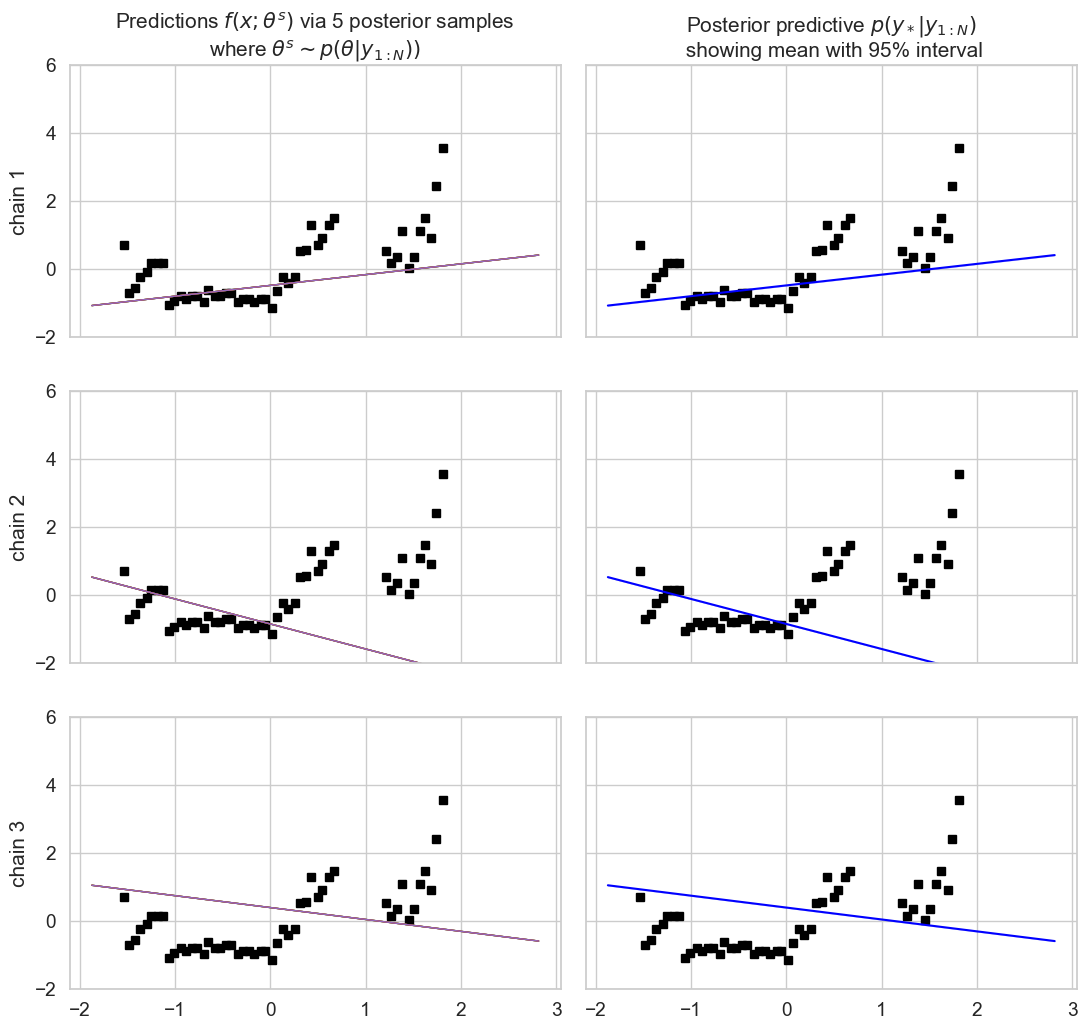

In [ ]:
viz_utils.show_posterior_predictive_samples_and_intervals(
    history0_nn_samples_by_chain, history0_y_ST_by_chain,
    x_grid_T=x_grid_T, x_NF=x_NF, y_N=y_N, sampler_options=opts)
plt.ylim([-2, 6]);
plt.subplots_adjust(wspace=0.05); # Tidy up the figure.

### **Caption for Fig 2b:** TODO in your report

TODO summarize how these estimated posteriors compare to the exact posterior for arch [] from HW2.


# Problem 3: NN regression on COVID-19 data with arch [8]

Same goals as problem 2, now with a more sophisticated model (1 hidden layer, 8 units).

In [ ]:
arch8 = [8]

In [ ]:
model3_hypers = copy.deepcopy(model1_hypers)

In [ ]:
model3_hypers['tau'] = 0.3     # LOWER THAN BEFORE
model3_hypers['w_stddev'] = 3. # same as before
model3_hypers['b_stddev'] = 3. # same as before

## Warm start: Use sklearn's MLPRegressor to find good MAP estimate for an arch [8] neural net

The code below should work out of the box.

In [ ]:
scores_by_trial = {}
q_by_trial = {}

for trial in range(10):

    # Fit MLP from random initialization
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", category=sklearn.exceptions.ConvergenceWarning)
        rgr = sklearn.neural_network.MLPRegressor(
            loss='squared_error',
            alpha=np.square(model3_hypers['tau']) / np.square(model3_hypers['w_stddev']), # equivalent to MAP for our model
            hidden_layer_sizes=arch8,
            activation='tanh',
            solver='lbfgs',
            max_iter=500,
            random_state=int(trial))
        rgr.fit(x_NF, y_N)

    # Form candidate q
    # -- set mean to values found by sklearn's MAP estimate
    # -- set stddev to small but not too small
    q_means = fill_q_params_with_draws_from_normal( # placeholder
        1, 1, arch8, mean=0., stddev=0.001, random_state=int(trial))
    # Write values from the rgr fit via sklearn into q
    for layer in range(len(q_means)):
        q_means[layer]['w'][:] = rgr.coefs_[layer][:]
        q_means[layer]['b'][:] = rgr.intercepts_[layer][:]

    q_rs = fill_q_params_with_draws_from_normal(
        1, 1, arch8,
        mean=invsoftplus(0.2), # FIX this typical stddev
        stddev=0.005,
        random_state=int(trial))

    # Estimate the ELBO with this candidate q
    nn_params_S = sample_nn_params_from_q(q_means, q_rs, random_state=random_state, n_samples=200)
    elbo = fast_elbo_from_mc_samples(nn_params_S, q_means, q_rs, x_NF, y_N, model3_hypers)
    print("After trial %2d, warm-started ELBO is % 9.4f" % (trial, elbo))

    scores_by_trial[trial] = elbo
    q_by_trial[trial] = (q_means, q_rs)

After trial  0, warm-started ELBO is    0.0000


After trial  1, warm-started ELBO is    0.0000


After trial  2, warm-started ELBO is    0.0000


After trial  3, warm-started ELBO is    0.0000


After trial  4, warm-started ELBO is    0.0000


After trial  5, warm-started ELBO is    0.0000


After trial  6, warm-started ELBO is    0.0000


After trial  7, warm-started ELBO is    0.0000


After trial  8, warm-started ELBO is    0.0000


After trial  9, warm-started ELBO is    0.0000


### Keep top 2 candidate q to use as warm starts

In [ ]:
n_chains = 2

# Find best trial ids as ranked by ELBO
# Remember, argsort ranks small to large, so we reverse with [::-1] to get top n_chains
best_trials_rankedByELBO = np.argsort(list(scores_by_trial.values()))[::-1][:n_chains]

In [ ]:
for trial in best_trials_rankedByELBO:
    print("Keep train %2d, ELBO is % 9.4f" % (trial, scores_by_trial[trial]))

Keep train  9, ELBO is    0.0000
Keep train  8, ELBO is    0.0000


## Prepare for multi-phase gradient ascent

**TODO FIXME** edit the following to achieve convergence

In [ ]:
ss = 0.01
ssm_by_phase = {0:ss, 1:ss}     # TODO FIXME
ssr_by_phase = {0:ss, 1:ss}     # TODO FIXME
S_by_phase = {0:10, 1:10}       # TODO FIXME
n_iters_by_phase = {0:50, 1:50} # TODO FIXME, probably need at least 1000 steps, perhaps more


In [ ]:
qm8_by_chain = {}
qr8_by_chain = {}
history8_by_chain = {}

chain_list = range(1, 1 + n_chains)

### Run multi-phase gradient ascent from each warm start

In [ ]:
for chain_id in chain_list:
    print("Chain %d/%d" % (chain_id, len(chain_list)))
    random_state = 100 * rep + chain_id

    # Use warm start!
    cur_trial = best_trials_rankedByELBO[chain_id-1] # Convert 1-idx chain_id to 0-index
    qwarmstart_m, qwarmstart_rs = q_by_trial[cur_trial]
    q8_m = copy.deepcopy(qwarmstart_m)
    q8_rs = copy.deepcopy(qwarmstart_rs)

    for phase in S_by_phase.keys():
        q8_m, q8_rs, hist8 = optimize_q_via_stochastic_gradient_ascent(
            q8_m, q8_rs,
            n_mc_samples=S_by_phase[phase],
            step_size_m=ssm_by_phase[phase],
            step_size_rs=ssr_by_phase[phase],
            random_state=random_state,
            print_every=100,
            n_iters=n_iters_by_phase[phase],
            x_NF=x_NF, y_N=y_N, model_hypers=model3_hypers)

        qm8_by_chain[chain_id] = q8_m
        qr8_by_chain[chain_id] = q8_rs
        history8_by_chain[(chain_id, phase)] = hist8

Chain 1/2
S =     10 | step_size of m 0.01 | step_size of rs 0.01
iter      0/50 after   0.1 sec  ELBO  0.000000e+00  m= [-1.150  0.082]  r= [-1.508 -1.509]  m= [ 1.489 -0.108]  r= [-1.500 -1.512]
iter      1/50 after   0.1 sec  ELBO  0.000000e+00  m= [-1.150  0.082]  r= [-1.508 -1.509]  m= [ 1.489 -0.108]  r= [-1.500 -1.512]
iter      2/50 after   0.1 sec  ELBO  0.000000e+00  m= [-1.150  0.082]  r= [-1.508 -1.509]  m= [ 1.489 -0.108]  r= [-1.500 -1.512]
iter     50/50 after   0.1 sec  ELBO  0.000000e+00  m= [-1.150  0.082]  r= [-1.508 -1.509]  m= [ 1.489 -0.108]  r= [-1.500 -1.512]
S =     10 | step_size of m 0.01 | step_size of rs 0.01
iter      0/50 after   0.0 sec  ELBO  0.000000e+00  m= [-1.150  0.082]  r= [-1.508 -1.509]  m= [ 1.489 -0.108]  r= [-1.500 -1.512]
iter      1/50 after   0.0 sec  ELBO  0.000000e+00  m= [-1.150  0.082]  r= [-1.508 -1.509]  m= [ 1.489 -0.108]  r= [-1.500 -1.512]
iter      2/50 after   0.0 sec  ELBO  0.000000e+00  m= [-1.150  0.082]  r= [-1.508 -1.509]  

iter     50/50 after   0.0 sec  ELBO  0.000000e+00  m= [ 5.171  1.640]  r= [-1.507 -1.502]  m= [-1.422 -1.100]  r= [-1.503 -1.509]
S =     10 | step_size of m 0.01 | step_size of rs 0.01
iter      0/50 after   0.0 sec  ELBO  0.000000e+00  m= [ 5.171  1.640]  r= [-1.507 -1.502]  m= [-1.422 -1.100]  r= [-1.503 -1.509]
iter      1/50 after   0.0 sec  ELBO  0.000000e+00  m= [ 5.171  1.640]  r= [-1.507 -1.502]  m= [-1.422 -1.100]  r= [-1.503 -1.509]
iter      2/50 after   0.0 sec  ELBO  0.000000e+00  m= [ 5.171  1.640]  r= [-1.507 -1.502]  m= [-1.422 -1.100]  r= [-1.503 -1.509]


iter     50/50 after   0.0 sec  ELBO  0.000000e+00  m= [ 5.171  1.640]  r= [-1.507 -1.502]  m= [-1.422 -1.100]  r= [-1.503 -1.509]


<a id="problem-3a"></a>

## Fig 3a

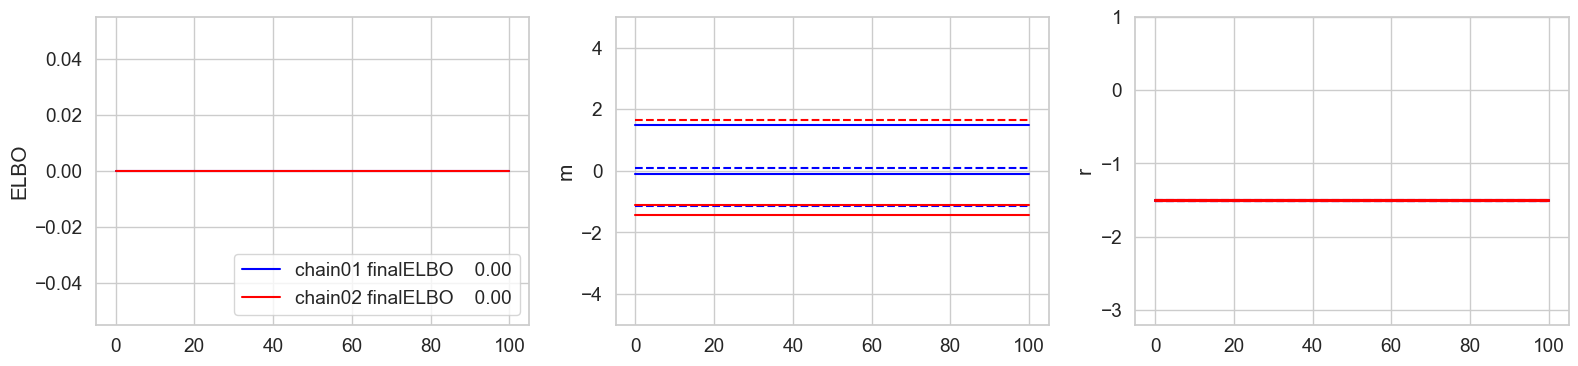

In [ ]:
color_by_chain = {1:'b', 2:'r', 3:'g'}
_, axgrid = plt.subplots(nrows=1, ncols=3, figsize=(3*W+1, H),
                         sharex=True, sharey=False)

phase_list = list(S_by_phase.keys())
for chain in chain_list:
    color = color_by_chain[chain]
    M = 0
    for phase in phase_list:
        iter_T = history8_by_chain[(chain,phase)]['iter']
        elbo_T = history8_by_chain[(chain,phase)]['elbo']
        label = 'chain%02d finalELBO % 7.2f' % (chain, elbo_T[-5:].mean()) if phase == len(phase_list) - 1 else None                                                if rep == 2 else None
        axgrid[0].plot(M + iter_T, elbo_T, color=color, linestyle='-', label=label)
        
        # Show means of first 2 weights of each layer
        for layer in [0, 1]:
            ls = '-' if layer == 1 else '--'
            m_T = [mlist[layer]['w'].flatten()[:2] for mlist in history8_by_chain[(chain,phase)]['q_m']]
            axgrid[1].plot(M + iter_T, m_T, color=color, linestyle=ls)
        
            # Show realstddevs of first 2 weights of last layer
            rs_T = [rlist[layer]['w'].flatten()[:2] for rlist in history8_by_chain[(chain,phase)]['q_rs']]
            axgrid[2].plot(M + iter_T, rs_T, color=color, linestyle=ls)
        M += iter_T.max();

axgrid[0].set_ylabel("ELBO"); axgrid[0].legend(loc='lower right')
axgrid[1].set_ylabel("m"); axgrid[1].set_ylim([-5.0, 5.0]);
axgrid[2].set_ylabel("r"); axgrid[2].set_ylim([-3.2, 1.0]);

#axgrid[0].set_ylim([-4.5, -1.9]); # TODO try to use these lims when code is working

### **Caption for Fig 3a**: TODO WRITE IN REPORT 

TODO 

* the specific number of Monte Carlo samples and step-sizes used
* 1-2 sentences summarizing your strategy for selecting these values
* your assessment of whether the plots indicate each chain has "converged"

## Prep for Fig 3b

Again, provided for you mostly out-of-the-box so you can immediately visualize the posteriors from your BBVI runs

**TODO FIXME**: draw y from its conditional given w

In [ ]:
S = 200
B = 0
opts = {'n_samples_burnin':B, 'n_samples_keep':S}
history8_nn_samples_by_chain = {}
history8_y_ST_by_chain = {}
for chain in chain_list:
    history8_nn_samples_by_chain[chain] = sample_nn_params_from_q(
        qm8_by_chain[chain],
        qr8_by_chain[chain],
        n_samples=S,
        random_state=random_state)
    y_ST = np.zeros((S,T))
    prng = np.random.RandomState(1000 * chain + 1)
    for ss in range(S):
        nn_ss = history8_nn_samples_by_chain[chain][B+ss]
        f_ss_T = predict_f_given_x(x_grid_T1, nn_ss)        
        y_ST[ss] = f_ss_T # TODO FIXME draw from y | w ; x
    history8_y_ST_by_chain[chain] = y_ST

<a id="problem-3b"></a>

## Fig 3b: Posterior predictive via optimal q for arch [8]

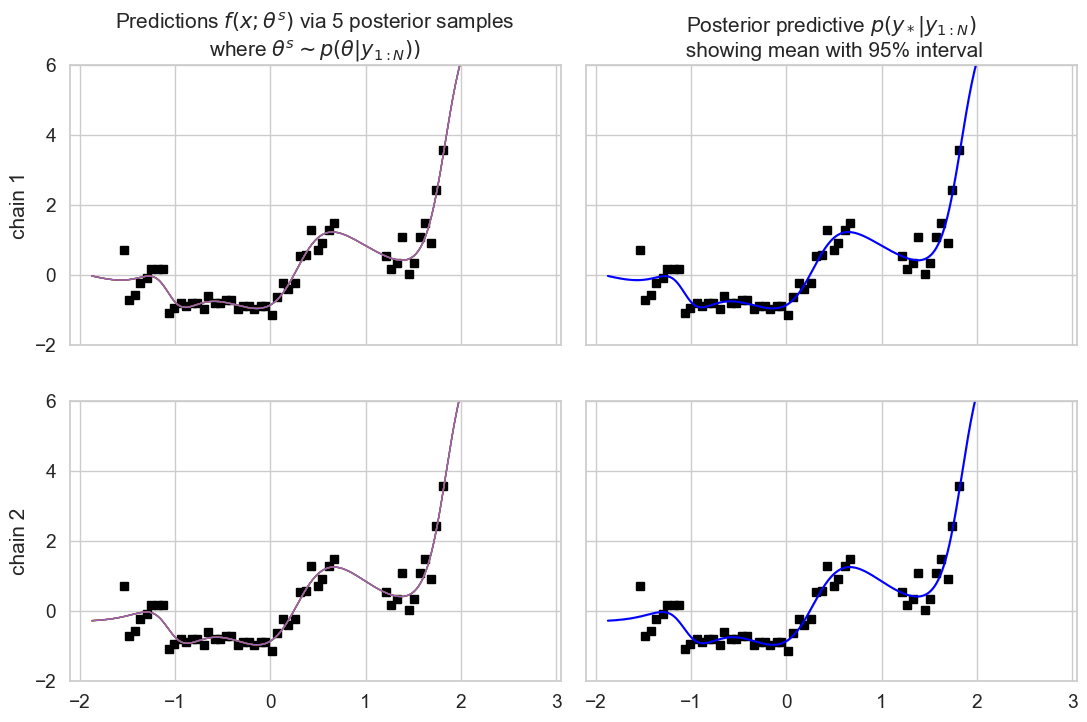

In [ ]:
viz_utils.show_posterior_predictive_samples_and_intervals(
    history8_nn_samples_by_chain, history8_y_ST_by_chain,
    x_grid_T=x_grid_T, x_NF=x_NF, y_N=y_N, sampler_options=opts)
plt.ylim([-2, 6]);
plt.subplots_adjust(wspace=0.05); # Tidy up the figure.

### **Caption for Fig 3b:** TODO WRITE IN REPORT

TODO summarize whether the *best* of your chains with arch [8] visually fits the data better than the simpler linear model
